In [ ]:
!pip install albumentations

In [ ]:
!pip install -U torchvision # We need a new versino of torchvision for this project

In [ ]:
import numpy as np
import pandas as pd
import os

In [ ]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
import torchvision
from torchvision import datasets, models
from torchvision.transforms import functional as FT
from torchvision import transforms as T
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, sampler, random_split, Dataset
import copy
import math
from PIL import Image
import cv2
import albumentations as A

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")
from collections import defaultdict, deque
import datetime
import time
from tqdm import tqdm
from torchvision.utils import draw_bounding_boxes

In [ ]:
!pip install pycocotools
from pycocotools.coco import COCO

PyCOCOTools provides many utilities for dealing with datasets in the COCO format

In [ ]:
from albumentations.pytorch import ToTensorV2

In [ ]:
def get_transforms_Augmentations(train=False):
    if train:
        transform = A.Compose([
            A.Resize(224, 224), # our input size can be 600px
            A.HorizontalFlip(p=0.2),
            A.VerticalFlip(p=0.3),
            A.RandomBrightnessContrast(p=0.1),
            A.ColorJitter(p=0.1),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='coco'))
    else:
        transform = A.Compose([
            A.Resize(224, 224), # our input size can be 600px
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='coco'))
    return transform

In [ ]:
class ObjectDetection(datasets.VisionDataset):
    def __init__(self, root, split='train', transform=None, target_transform=None, transforms=None):
        super().__init__(root, transforms, transform, target_transform)
        self.split = split #train, valid, test
        self.coco = COCO(os.path.join(root, split, "_annotations.coco.json"))
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.ids = [id for id in self.ids if (len(self._load_target(id)) > 0)]

    def _load_image(self, id: int):
        path = self.coco.loadImgs(id)[0]['file_name']
        image = cv2.imread(os.path.join(self.root, self.split, path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return image
    def _load_target(self, id):
        return self.coco.loadAnns(self.coco.getAnnIds(id))

    def __getitem__(self, index):
        id = self.ids[index]
        image = self._load_image(id)
        target = self._load_target(id)
        target = copy.deepcopy(self._load_target(id))

        boxes = [t['bbox'] + [t['category_id']] for t in target]
        if self.transforms is not None:
            transformed = self.transforms(image=image, bboxes=boxes)

        image = transformed['image']
        boxes = transformed['bboxes']

        new_boxes = []
        for box in boxes:
            xmin = box[0]
            xmax = xmin + box[2]
            ymin = box[1]
            ymax = ymin + box[3]
            new_boxes.append([xmin, ymin, xmax, ymax])

        boxes = torch.tensor(new_boxes, dtype=torch.float32)

        targ = {} # here is our transformed target
        targ['boxes'] = boxes
        targ['labels'] = torch.tensor([t['category_id'] for t in target], dtype=torch.int64)
        targ['image_id'] = torch.tensor([t['image_id'] for t in target])
        targ['area'] = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) # we have a different area
        targ['iscrowd'] = torch.tensor([t['iscrowd'] for t in target], dtype=torch.int64)
        return image.div(255), targ # scale images
    def __len__(self):
        return len(self.ids)

In [ ]:
dataset_path = "Part-3"

In [ ]:
#load classes
coco = COCO(os.path.join(dataset_path, "train", "_annotations.coco.json"))
categories = coco.cats
n_classes = len(categories.keys())
categories

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


{0: {'id': 0,
  'name': 'Vehicle-Car-Truck-Bike-Motorbike',
  'supercategory': 'none'},
 1: {'id': 1,
  'name': 'Bike',
  'supercategory': 'Vehicle-Car-Truck-Bike-Motorbike'},
 2: {'id': 2,
  'name': 'Motorbike',
  'supercategory': 'Vehicle-Car-Truck-Bike-Motorbike'},
 3: {'id': 3,
  'name': 'Traffic Light',
  'supercategory': 'Vehicle-Car-Truck-Bike-Motorbike'},
 4: {'id': 4,
  'name': 'Traffic Sign',
  'supercategory': 'Vehicle-Car-Truck-Bike-Motorbike'},
 5: {'id': 5,
  'name': 'vehicle',
  'supercategory': 'Vehicle-Car-Truck-Bike-Motorbike'}}

In [ ]:
classes = [i[1]['name'] for i in categories.items()]
classes

['Vehicle-Car-Truck-Bike-Motorbike',
 'Bike',
 'Motorbike',
 'Traffic Light',
 'Traffic Sign',
 'vehicle']

In [ ]:
train_dataset = ObjectDetection(root=dataset_path, transforms=get_transforms_Augmentations(True))

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


This is a sample image and its bounding boxes,not the model's output

### Faster R-CNN_ MobileNet_V3

In [ ]:
device = torch.device("cuda")

In [ ]:
model = model.to(device)

In [ ]:
# load the faster rcnn model
model = models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=False)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, n_classes)

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4, collate_fn=collate_fn)

In [ ]:
!set PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [ ]:
images,targets = next(iter(train_loader))
images = list(image for image in images)
targets = [{k:v for k, v in t.items()} for t in targets]
output = model(images, targets) # just make sure this runs without error

In [ ]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.01, momentum=0.9, nesterov=True, weight_decay=1e-4)


In [ ]:
def train_one_epoch(model, optimizer, loader, device, epoch):
    model.to(device)
    model.train()

    all_losses = []
    all_losses_dict = []

    for images, targets in tqdm(loader):
        images = list(image.to(device) for image in images)
        targets = [{k: torch.tensor(v).to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets) # the model computes the loss automatically if we pass in targets
        losses = sum(loss for loss in loss_dict.values())
        loss_dict_append = {k: v.item() for k, v in loss_dict.items()}
        loss_value = losses.item()

        all_losses.append(loss_value)
        all_losses_dict.append(loss_dict_append)

        if not math.isfinite(loss_value):
            print(f"Loss is {loss_value}, stopping training") # train if loss becomes infinity
            print(loss_dict)
            sys.exit(1)

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    all_losses_dict = pd.DataFrame(all_losses_dict) # for printing
    print("Epoch {}, lr: {:.6f}, loss: {:.6f}, loss_classifier: {:.6f}, loss_box: {:.6f}, loss_rpn_box: {:.6f}, loss_object: {:.6f}".format(
        epoch, optimizer.param_groups[0]['lr'], np.mean(all_losses),
        all_losses_dict['loss_classifier'].mean(),
        all_losses_dict['loss_box_reg'].mean(),
        all_losses_dict['loss_rpn_box_reg'].mean(),
        all_losses_dict['loss_objectness'].mean()
    ))


In [ ]:
num_epochs=300

for epoch in range(num_epochs):
    train_one_epoch(model, optimizer, train_loader, device, epoch)

100%|██████████| 107/107 [00:05<00:00, 19.63it/s]


Epoch 0, lr: 0.010000, loss: 0.327436, loss_classifier: 0.115140, loss_box: 0.061286, loss_rpn_box: 0.018189, loss_object: 0.132822


100%|██████████| 107/107 [00:04<00:00, 23.42it/s]


Epoch 1, lr: 0.010000, loss: 0.191025, loss_classifier: 0.070802, loss_box: 0.070493, loss_rpn_box: 0.013391, loss_object: 0.036340


100%|██████████| 107/107 [00:04<00:00, 23.65it/s]


...

Epoch 297, lr: 0.010000, loss: 0.352160, loss_classifier: 0.109988, loss_box: 0.238811, loss_rpn_box: 0.001118, loss_object: 0.002243


100%|██████████| 107/107 [00:03<00:00, 27.05it/s]


Epoch 298, lr: 0.010000, loss: 0.368086, loss_classifier: 0.115211, loss_box: 0.249723, loss_rpn_box: 0.001089, loss_object: 0.002063


100%|██████████| 107/107 [00:04<00:00, 26.70it/s]

Epoch 299, lr: 0.010000, loss: 0.370236, loss_classifier: 0.112645, loss_box: 0.254411, loss_rpn_box: 0.001104, loss_object: 0.002076


In [ ]:
model.eval()
torch.cuda.empty_cache()

In [ ]:
test_dataset = ObjectDetection(root=dataset_path, split="test", transforms=get_transforms(False))

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [ ]:
img, _ = test_dataset[7]
img_int = torch.tensor(img*255, dtype=torch.uint8)
with torch.no_grad():
    prediction = model([img.to(device)])
    pred = prediction[0]

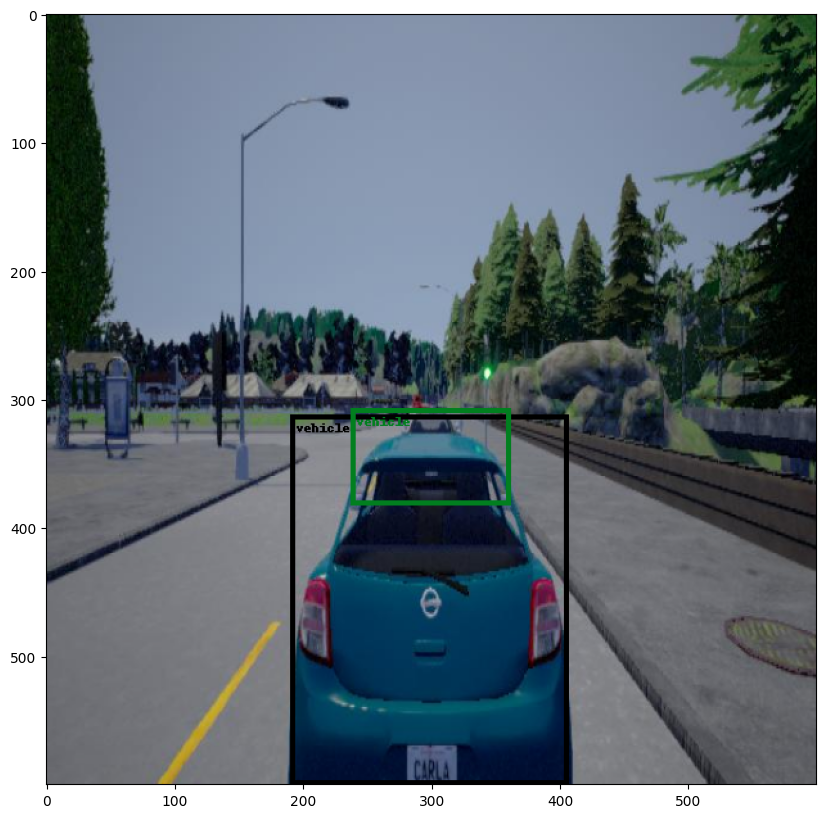

In [ ]:
fig = plt.figure(figsize=(14, 10))
plt.imshow(draw_bounding_boxes(img_int,
    pred['boxes'][pred['scores'] > 0.8],
    [classes[i] for i in pred['labels'][pred['scores'] > 0.8].tolist()], width=4
).permute(1, 2, 0))

In [ ]:
import random

predictions = []

# Iterate through the entire test dataset
for img, _ in test_dataset:
    # Perform prediction
    with torch.no_grad():
        prediction = model([img.to(device)])
        predictions.append(prediction)

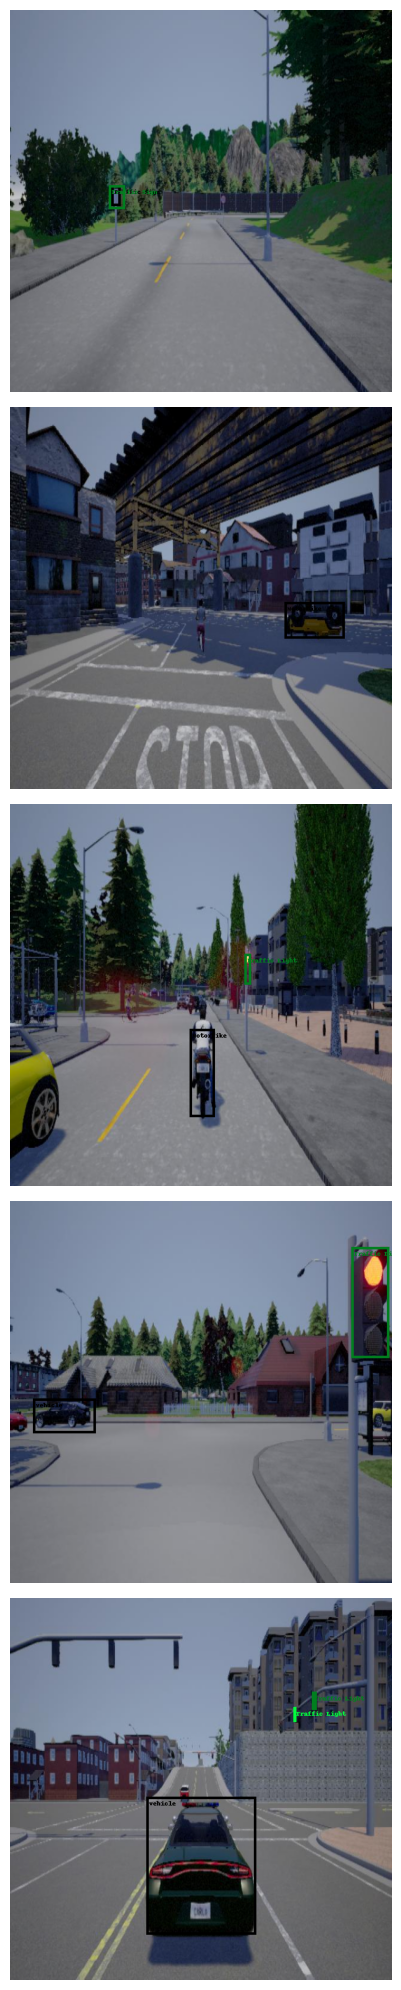

In [ ]:
# Randomly select 5 images
random_indices = random.sample(range(len(test_dataset)), 5)

# Plot randomly selected images with bounding boxes
fig, axes = plt.subplots(5, 1, figsize=(20, 20))

for i, idx in enumerate(random_indices):
    img, _ = test_dataset[idx]
    img_int = torch.tensor(img * 255, dtype=torch.uint8)
    prediction = predictions[idx][0]
    axes[i].imshow(draw_bounding_boxes(img_int,
        prediction['boxes'][prediction['scores'] > 0.8],
        [classes[label] for label in prediction['labels'][prediction['scores'] > 0.8].tolist()], width=4
    ).permute(1, 2, 0))
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
def calculate_iou(box1, box2):
    # Calculate intersection coordinates
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    # Calculate intersection area
    intersection_area = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1)

    # Calculate area of each bounding box
    area_box1 = (box1[2] - box1[0] + 1) * (box1[3] - box1[1] + 1)
    area_box2 = (box2[2] - box2[0] + 1) * (box2[3] - box2[1] + 1)

    # Calculate union area
    union_area = area_box1 + area_box2 - intersection_area

    # Calculate IoU
    iou = intersection_area / union_area

    return iou

def calculate_accuracy(predictions, test_dataset, threshold=0.5):
    total_correct = 0
    total_gt_boxes = 0

    for idx, (_, target) in enumerate(test_dataset):
        gt_boxes = target['boxes'].tolist()
        gt_labels = target['labels'].tolist()

        prediction = predictions[idx][0]
        pred_boxes = prediction['boxes'][prediction['scores'] > 0.8].tolist()
        pred_labels = prediction['labels'][prediction['scores'] > 0.8].tolist()

        for gt_box, gt_label in zip(gt_boxes, gt_labels):
            matched = False
            for pred_box, pred_label in zip(pred_boxes, pred_labels):
                if gt_label == pred_label:
                    iou = calculate_iou(gt_box, pred_box)
                    if iou > threshold:
                        matched = True
                        break
            if matched:
                total_correct += 1
        total_gt_boxes += len(gt_boxes)

    accuracy = total_correct / total_gt_boxes
    return accuracy


In [ ]:
accuracy = calculate_accuracy(predictions, test_dataset, threshold=0.3)
print("Accuracy:", accuracy)


Accuracy: 0.8014184397163121


In [ ]:
def print_iou_values(predictions, test_dataset):
    for idx, (_, target) in enumerate(test_dataset):
        gt_boxes = target['boxes'].tolist()

        prediction = predictions[idx][0]
        pred_boxes = prediction['boxes'][prediction['scores'] > 0.8].tolist()

        print(f"IoU values for image {idx + 1}:")
        print("GT Box | Prediction | IoU")
        print("---------------------------")
        for gt_idx, gt_box in enumerate(gt_boxes):
            max_iou = 0
            for pred_idx, pred_box in enumerate(pred_boxes):
                iou = calculate_iou(gt_box, pred_box)
                max_iou = max(max_iou, iou)
                print(f"  {gt_idx + 1}     |   {pred_idx + 1}        |  {iou:.4f}")
            print(f"Max IoU for GT box {gt_idx + 1}: {max_iou:.4f}")
        print()

print_iou_values(predictions, test_dataset)


IoU values for image 1:
GT Box | Prediction | IoU
---------------------------
  1     |   1        |  0.9256
Max IoU for GT box 1: 0.9256

IoU values for image 2:
GT Box | Prediction | IoU
---------------------------
  1     |   1        |  0.8826
  1     |   2        |  0.0000
Max IoU for GT box 1: 0.8826
  2     |   1        |  0.0000
  2     |   2        |  0.7530
Max IoU for GT box 2: 0.7530

IoU values for image 3:
GT Box | Prediction | IoU
---------------------------
  1     |   1        |  0.0000
Max IoU for GT box 1: 0.0000
  2     |   1        |  0.9176
Max IoU for GT box 2: 0.9176

IoU values for image 4:
GT Box | Prediction | IoU
---------------------------
  1     |   1        |  0.8736
Max IoU for GT box 1: 0.8736

IoU values for image 5:
GT Box | Prediction | IoU
---------------------------
  1     |   1        |  0.8648
  1     |   2        |  0.0000
  1     |   3        |  0.0000
  1     |   4        |  0.0000
  1     |   5        |  0.0000
Max IoU for GT box 1: 0.8648


In [ ]:
def calculate_mean_iou(predictions, test_dataset):
    total_iou = 0
    total_gt_boxes = 0

    for idx, (_, target) in enumerate(test_dataset):
        gt_boxes = target['boxes'].tolist()

        prediction = predictions[idx][0]
        pred_boxes = prediction['boxes'][prediction['scores'] > 0.8].tolist()

        for gt_box in gt_boxes:
            max_iou = 0
            for pred_box in pred_boxes:
                iou = calculate_iou(gt_box, pred_box)
                max_iou = max(max_iou, iou)
            total_iou += max_iou
        total_gt_boxes += len(gt_boxes)

    mean_iou = total_iou / total_gt_boxes
    return mean_iou

mean_iou = calculate_mean_iou(predictions, test_dataset)
print("Mean IoU:", mean_iou)


Mean IoU: 0.7070545903906131


In [ ]:

# Save model with weights
torch.save(model.state_dict(), 'model_weights_team13.pth')

# Save bounding box coordinates in CSV format
all_predictions = []
for idx, (_, target) in enumerate(test_dataset):
    prediction = predictions[idx][0]
    pred_boxes = prediction['boxes'][prediction['scores'] > 0.8].tolist()
    pred_labels = prediction['labels'][prediction['scores'] > 0.8].tolist()
    image_id = idx + 1
    for box, label in zip(pred_boxes, pred_labels):
        all_predictions.append({
            'Image ID': image_id,
            'Label': label,
            'Xmin': box[0],
            'Ymin': box[1],
            'Xmax': box[2],
            'Ymax': box[3]
        })

# Convert predictions to DataFrame
df_predictions = pd.DataFrame(all_predictions)

# Save DataFrame to CSV
df_predictions.to_csv('bounding_boxes_13.csv', index=False)
